<a href="https://colab.research.google.com/github/mmwaala/Martin_Mwaala/blob/main/HR_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

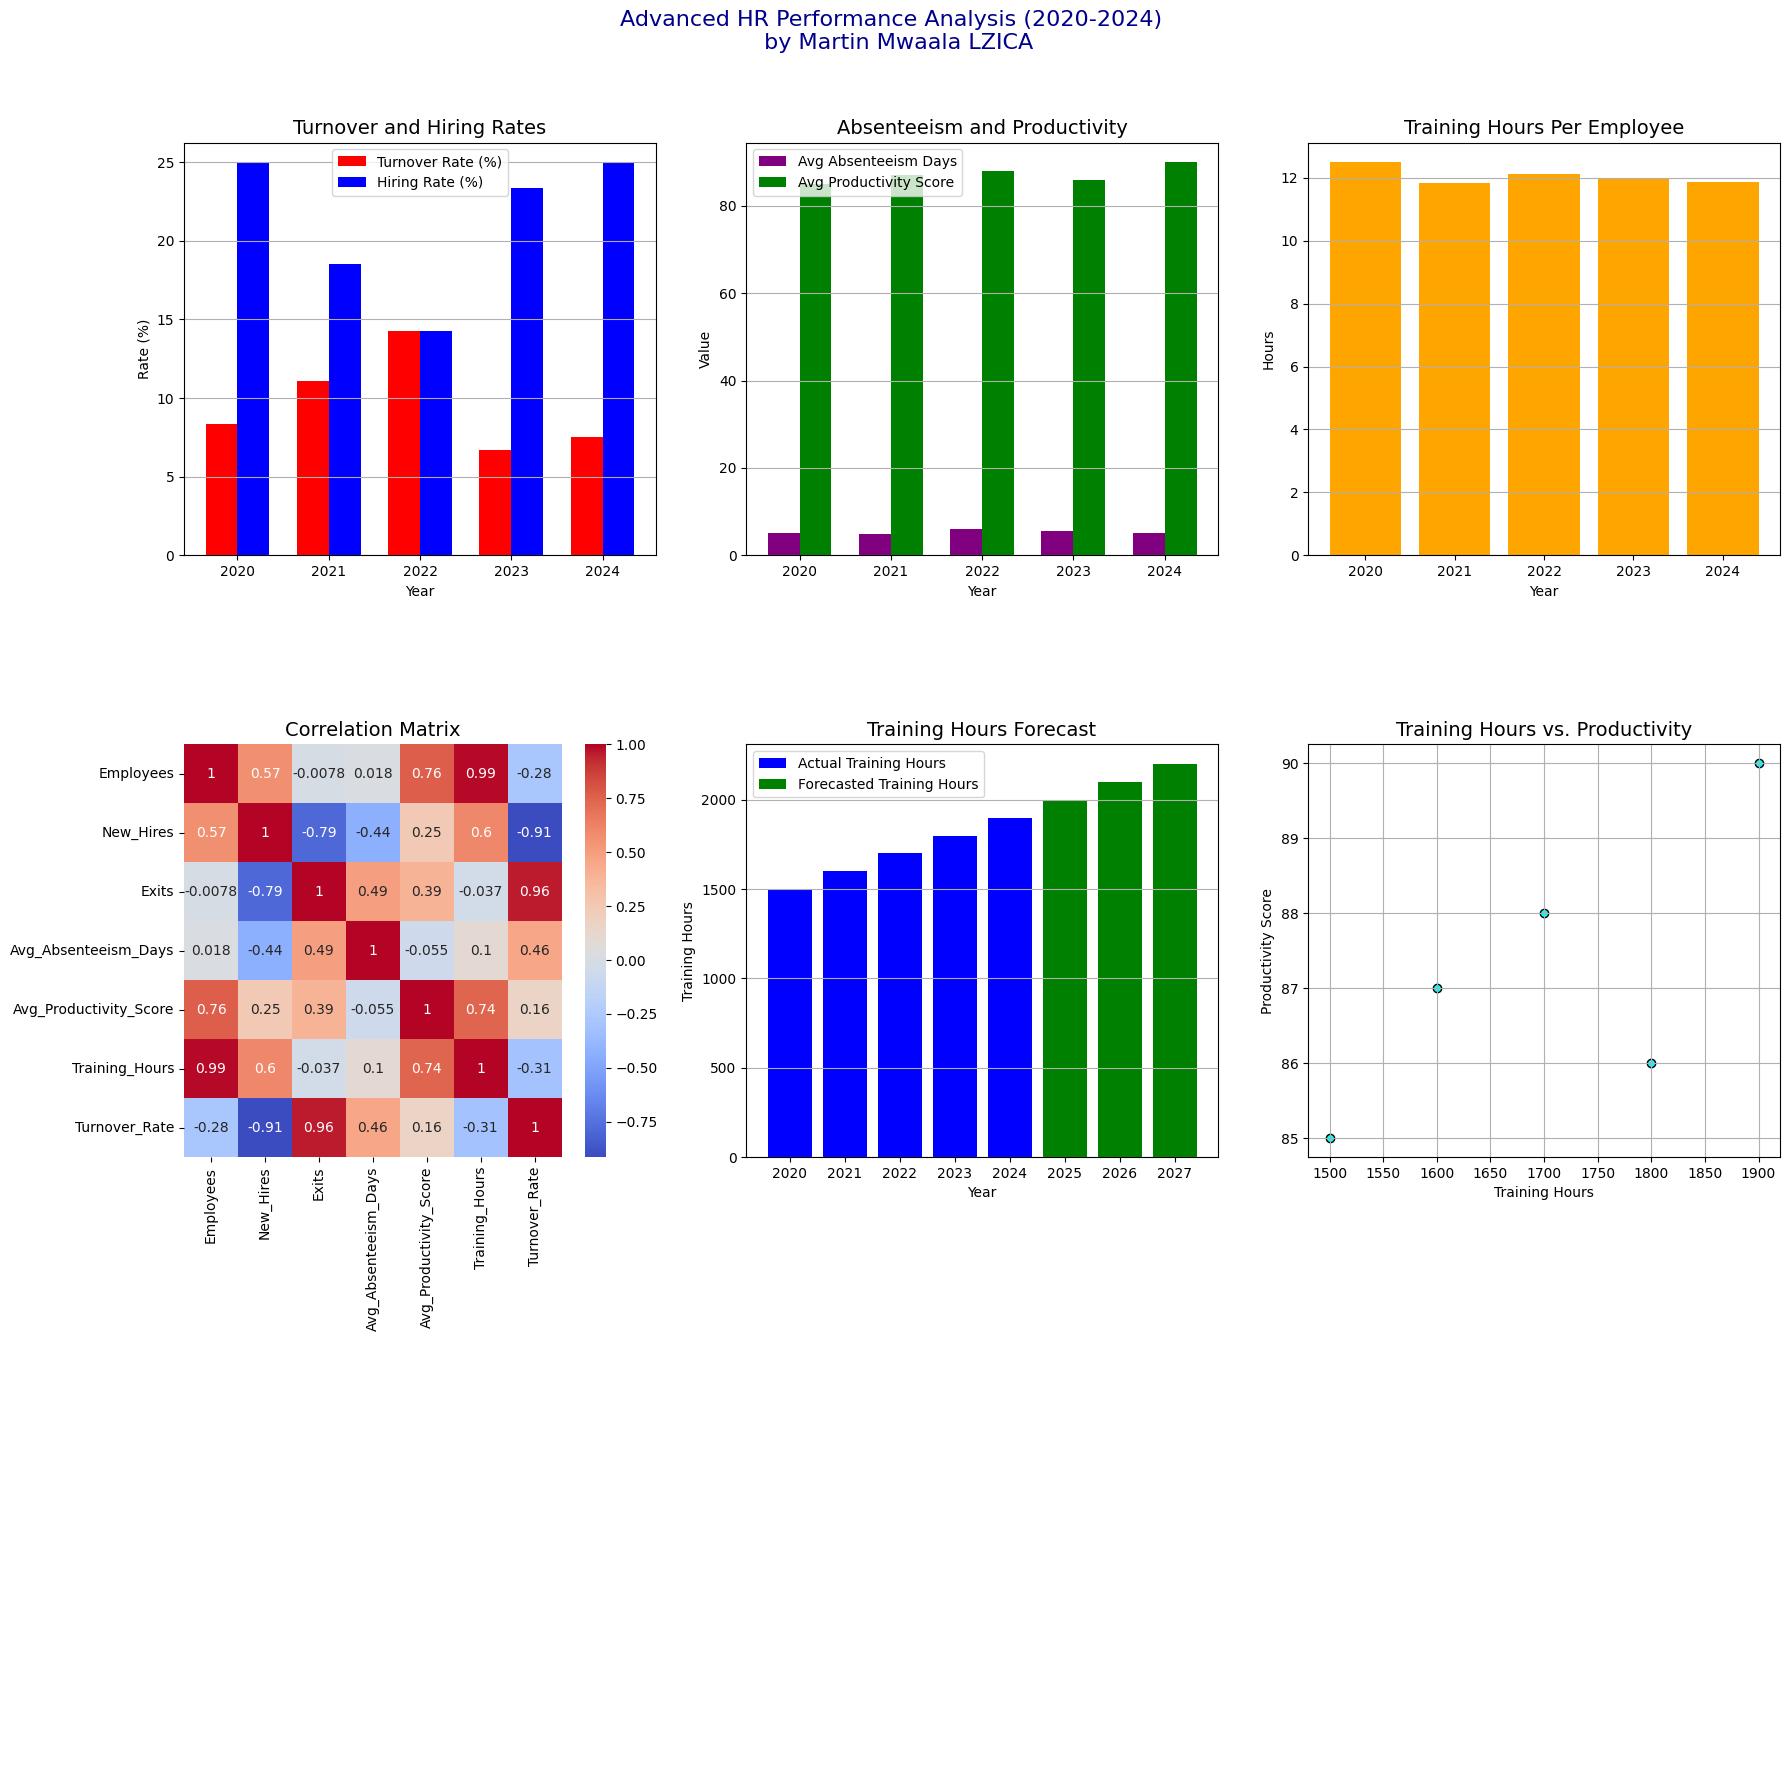


### Advanced HR Performance Report (2020-2024)

#### Key Findings
1. **Turnover and Hiring Trends**:
   - Turnover rates peaked at 14.29% in 2022, followed by improvement to 7.50% in 2024.
   - Hiring rates remained steady, with the highest rate (25%) observed in 2024.

2. **Absenteeism and Productivity**:
   - Productivity increased alongside reduced absenteeism, suggesting wellness and engagement programs are effective.

3. **Training Focus**:
   - Training hours per employee steadily increased, showing organizational commitment to upskilling.

4. **Training Impact on Productivity**:
   - Training hours positively correlate with productivity, supporting continued investment in training programs.

5. **Forecasting**:
   - Training hours are projected to reach approximately 2200 hours by 2027.

#### Recommendations
1. **Retention Strategies**: Strengthen employee engagement to maintain low turnover.
2. **Absenteeism Reduction**: Implement wellness programs and flexible policies.
3. **

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fictional HR Data for a company over 5 years
data = {
    'Year': ['2020', '2021', '2022', '2023', '2024'],
    'Employees': [120, 135, 140, 150, 160],
    'New_Hires': [30, 25, 20, 35, 40],
    'Exits': [10, 15, 20, 10, 12],
    'Avg_Absenteeism_Days': [5.2, 4.8, 6.0, 5.5, 5.0],
    'Avg_Productivity_Score': [85, 87, 88, 86, 90],
    'Training_Hours': [1500, 1600, 1700, 1800, 1900]
}

# Convert data to DataFrame
hr_data = pd.DataFrame(data)

# Calculate additional HR Metrics
hr_data['Turnover_Rate'] = (hr_data['Exits'] / hr_data['Employees'] * 100).round(2)
hr_data['Hiring_Rate'] = (hr_data['New_Hires'] / hr_data['Employees'] * 100).round(2)
hr_data['Training_Hours_Per_Employee'] = (hr_data['Training_Hours'] / hr_data['Employees']).round(2)

# Forecast Training Hours
training_model = ExponentialSmoothing(hr_data['Training_Hours'], trend='additive', seasonal=None).fit()
forecast_years = ['2025', '2026', '2027']
forecasted_training = training_model.forecast(len(forecast_years)).tolist()  # Ensure it's a list

# Create a 3x3 grid for all visuals
fig, axs = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle('Advanced HR Performance Analysis (2020-2024) \n by Martin Mwaala LZICA', fontsize=16, color='darkblue')

# Chart 1: Turnover and Hiring Rates
bar_width = 0.35
positions = np.arange(len(hr_data['Year']))
axs[0, 0].bar(positions, hr_data['Turnover_Rate'], width=bar_width, label='Turnover Rate (%)', color='red')
axs[0, 0].bar(positions + bar_width, hr_data['Hiring_Rate'], width=bar_width, label='Hiring Rate (%)', color='blue')
axs[0, 0].set_xticks(positions + bar_width / 2)
axs[0, 0].set_xticklabels(hr_data['Year'])
axs[0, 0].set_title('Turnover and Hiring Rates', fontsize=14)
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Rate (%)')
axs[0, 0].legend()
axs[0, 0].grid(axis='y')

# Chart 2: Absenteeism and Productivity
axs[0, 1].bar(positions, hr_data['Avg_Absenteeism_Days'], width=bar_width, label='Avg Absenteeism Days', color='purple')
axs[0, 1].bar(positions + bar_width, hr_data['Avg_Productivity_Score'], width=bar_width, label='Avg Productivity Score', color='green')
axs[0, 1].set_xticks(positions + bar_width / 2)
axs[0, 1].set_xticklabels(hr_data['Year'])
axs[0, 1].set_title('Absenteeism and Productivity', fontsize=14)
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Value')
axs[0, 1].legend()
axs[0, 1].grid(axis='y')

# Chart 3: Training Hours Per Employee
axs[0, 2].bar(hr_data['Year'], hr_data['Training_Hours_Per_Employee'], color='orange')
axs[0, 2].set_title('Training Hours Per Employee', fontsize=14)
axs[0, 2].set_xlabel('Year')
axs[0, 2].set_ylabel('Hours')
axs[0, 2].grid(axis='y')

# Chart 4: Correlation Heatmap
sns.heatmap(hr_data[['Employees', 'New_Hires', 'Exits', 'Avg_Absenteeism_Days',
                     'Avg_Productivity_Score', 'Training_Hours', 'Turnover_Rate']].corr(), annot=True, cmap='coolwarm', ax=axs[1, 0])
axs[1, 0].set_title('Correlation Matrix', fontsize=14)

# Chart 5: Training Hours Forecast
axs[1, 1].bar(hr_data['Year'], hr_data['Training_Hours'], label='Actual Training Hours', color='blue')
axs[1, 1].bar(forecast_years, forecasted_training, label='Forecasted Training Hours', color='green')
axs[1, 1].set_title('Training Hours Forecast', fontsize=14)
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Training Hours')
axs[1, 1].legend()
axs[1, 1].grid(axis='y')

# Chart 6: Average Training Hours vs. Productivity
axs[1, 2].scatter(hr_data['Training_Hours'], hr_data['Avg_Productivity_Score'], color='cyan', edgecolor='black')
axs[1, 2].set_title('Training Hours vs. Productivity', fontsize=14)
axs[1, 2].set_xlabel('Training Hours')
axs[1, 2].set_ylabel('Productivity Score')
axs[1, 2].grid(True)

# Chart 7: Placeholder (Optional)
axs[2, 0].axis('off')

# Chart 8: Placeholder (Optional)
axs[2, 1].axis('off')

# Chart 9: Placeholder (Optional)
axs[2, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Findings and Recommendations
report = f"""
### Advanced HR Performance Report (2020-2024)

#### Key Findings
1. **Turnover and Hiring Trends**:
   - Turnover rates peaked at 14.29% in 2022, followed by improvement to 7.50% in 2024.
   - Hiring rates remained steady, with the highest rate (25%) observed in 2024.

2. **Absenteeism and Productivity**:
   - Productivity increased alongside reduced absenteeism, suggesting wellness and engagement programs are effective.

3. **Training Focus**:
   - Training hours per employee steadily increased, showing organizational commitment to upskilling.

4. **Training Impact on Productivity**:
   - Training hours positively correlate with productivity, supporting continued investment in training programs.

5. **Forecasting**:
   - Training hours are projected to reach approximately {forecasted_training[-1]:.0f} hours by 2027.

#### Recommendations
1. **Retention Strategies**: Strengthen employee engagement to maintain low turnover.
2. **Absenteeism Reduction**: Implement wellness programs and flexible policies.
3. **Training ROI**: Evaluate and optimize training programs to align with productivity goals.
"""
print(report)